In [1]:
import joblib

classification_model = joblib.load(
    "../models/xgb_classification.pkl"
)

label_encoder = joblib.load(
    "../models/risk_label_encoder.pkl"
)

print("Classification model loaded successfully")
print("Classes:", label_encoder.classes_)

Classification model loaded successfully
Classes: ['High' 'Low' 'Medium']


In [ ]:
features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

X = df[features]

print("X shape:", X.shape)
print(X.head())

In [2]:
import pandas as pd

df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Classification.xlsx"
)

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (3162, 10)
['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate']


In [3]:
preprocessor = classification_model.named_steps["preprocessor"]
classifier = classification_model.named_steps["classifier"]

print(type(preprocessor))
print(type(classifier))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'xgboost.sklearn.XGBClassifier'>


In [4]:
X_transformed = preprocessor.transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_transformed.shape)

NameError: name 'X' is not defined

In [5]:
import pandas as pd

features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

X = df[features]

print("X shape:", X.shape)
print(X.head())

X shape: (3162, 10)
  state  year  residential_billion_btu  commercial_billion_btu  \
0    AK  1962                    10472                    7129   
1    AK  1963                    11256                    9246   
2    AK  1964                    13004                   12021   
3    AK  1965                    13857                   14210   
4    AK  1966                    15563                   15066   

   industrial_billion_btu  transportation_billion_btu  co2_lag_1  co2_lag_2  \
0                   24859                       34182      4.846      4.040   
1                   25598                       32387      5.327      4.846   
2                   25522                       32246      5.366      5.327   
3                   22874                       34379      5.620      5.366   
4                   33619                       36233      5.720      5.620   

   energy_growth_rate  co2_growth_rate  
0            9.457298         9.925712  
1            2.408601     

In [6]:
preprocessor = classification_model.named_steps["preprocessor"]
classifier = classification_model.named_steps["classifier"]
X_transformed = preprocessor.transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_transformed.shape)

Original shape: (3162, 10)
Transformed shape: (3162, 60)


In [7]:
import joblib

classification_model = joblib.load(
    "../models/xgb_classification.pkl"
)

label_encoder = joblib.load(
    "../models/risk_label_encoder.pkl"
)
import pandas as pd

df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Classification.xlsx"
)
features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

X = df[features]
preprocessor = classification_model.named_steps["preprocessor"]
classifier = classification_model.named_steps["classifier"]
X_transformed = preprocessor.transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_transformed.shape)

Original shape: (3162, 10)
Transformed shape: (3162, 60)


In [8]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))

for i, name in enumerate(feature_names):
    print(i, name)

Number of feature names: 60
0 state__state_AK
1 state__state_AL
2 state__state_AR
3 state__state_AZ
4 state__state_CA
5 state__state_CO
6 state__state_CT
7 state__state_DC
8 state__state_DE
9 state__state_FL
10 state__state_GA
11 state__state_HI
12 state__state_IA
13 state__state_ID
14 state__state_IL
15 state__state_IN
16 state__state_KS
17 state__state_KY
18 state__state_LA
19 state__state_MA
20 state__state_MD
21 state__state_ME
22 state__state_MI
23 state__state_MN
24 state__state_MO
25 state__state_MS
26 state__state_MT
27 state__state_NC
28 state__state_ND
29 state__state_NE
30 state__state_NH
31 state__state_NJ
32 state__state_NM
33 state__state_NV
34 state__state_NY
35 state__state_OH
36 state__state_OK
37 state__state_OR
38 state__state_PA
39 state__state_RI
40 state__state_SC
41 state__state_SD
42 state__state_TN
43 state__state_TX
44 state__state_UT
45 state__state_VA
46 state__state_VT
47 state__state_WA
48 state__state_WI
49 state__state_WV
50 state__state_WY
51 remainder_

In [9]:
import shap
explainer = shap.TreeExplainer(classifier)

print("SHAP explainer created successfully")

c:\Users\angel\OneDrive\Desktop\carbonOPT\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP explainer created successfully


In [10]:
shap_values = explainer.shap_values(X_transformed)

print("SHAP type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    for i, values in enumerate(shap_values):
        print(f"Class {i} shape:", values.shape)
else:
    print("SHAP shape:", shap_values.shape)

SHAP type: <class 'numpy.ndarray'>
SHAP shape: (3162, 60, 3)


In [11]:
shap_values[sample, feature, class]

SyntaxError: invalid syntax (1389273830.py, line 1)

In [12]:
print("Encoded classes:", label_encoder.classes_)

for i, class_name in enumerate(label_encoder.classes_):
    print(i, "→", class_name)

Encoded classes: ['High' 'Low' 'Medium']
0 → High
1 → Low
2 → Medium


In [13]:
import numpy as np
import pandas as pd

global_importance = np.mean(
    np.abs(shap_values),
    axis=(0, 2)
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": global_importance
})

importance_df = importance_df.sort_values(
    "mean_abs_shap",
    ascending=False
)

print(importance_df.head(15).to_string(index=False))

                              feature  mean_abs_shap
                 remainder__co2_lag_1       2.487581
                 remainder__co2_lag_2       1.134047
remainder__transportation_billion_btu       0.300622
    remainder__industrial_billion_btu       0.299502
                      remainder__year       0.241213
        remainder__energy_growth_rate       0.160480
           remainder__co2_growth_rate       0.149113
    remainder__commercial_billion_btu       0.099054
   remainder__residential_billion_btu       0.063522
                      state__state_NV       0.013854
                      state__state_CT       0.011082
                      state__state_OR       0.009315
                      state__state_WV       0.006233
                      state__state_OK       0.005305
                      state__state_AR       0.004648


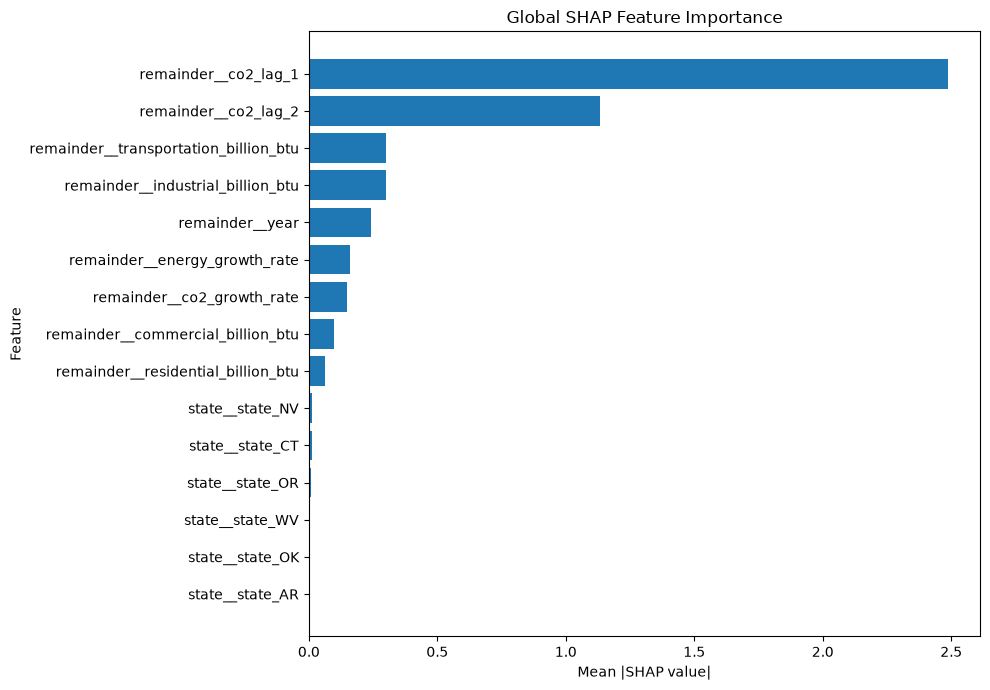

In [14]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15).sort_values(
    "mean_abs_shap"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["mean_abs_shap"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance")

plt.tight_layout()
plt.show()

In [15]:
# Find the encoded class index for High
high_class_index = list(label_encoder.classes_).index("High")

print("High Risk class index:", high_class_index)
# Get predictions for all observations
pred_encoded = classification_model.predict(X)
pred_labels = label_encoder.inverse_transform(pred_encoded)

df["predicted_risk"] = pred_labels

print(df["predicted_risk"].value_counts())
high_indices = np.where(pred_labels == "High")[0]

print("Number of High-Risk predictions:", len(high_indices))
print("First High-Risk index:", high_indices[0])

High Risk class index: 0
predicted_risk
Medium    1128
High      1025
Low       1009
Name: count, dtype: int64
Number of High-Risk predictions: 1025
First High-Risk index: 69


In [16]:
high_index = high_indices[0]

print("Observation index:", high_index)
print("\nObservation:")
print(df.loc[high_index, features])

Observation index: 69

Observation:
state                               AL
year                              1969
residential_billion_btu         192446
commercial_billion_btu          100346
industrial_billion_btu          750145
transportation_billion_btu      255625
co2_lag_1                        93.71
co2_lag_2                       86.192
energy_growth_rate            7.493473
co2_growth_rate                5.04642
Name: 69, dtype: object


In [17]:
high_shap_values = shap_values[high_index, :, high_class_index]

print("SHAP values shape:", high_shap_values.shape)

SHAP values shape: (60,)


In [18]:
high_explanation = pd.DataFrame({
    "feature": feature_names,
    "shap_value": high_shap_values
})

high_explanation["abs_shap"] = (
    high_explanation["shap_value"].abs()
)

high_explanation = high_explanation.sort_values(
    "abs_shap",
    ascending=False
)

print(
    high_explanation.head(15).to_string(index=False)
)

                              feature  shap_value  abs_shap
                 remainder__co2_lag_1    1.006878  1.006878
        remainder__energy_growth_rate    0.894879  0.894879
                 remainder__co2_lag_2   -0.752192  0.752192
    remainder__industrial_billion_btu    0.594244  0.594244
remainder__transportation_billion_btu   -0.448804  0.448804
           remainder__co2_growth_rate    0.383621  0.383621
                      remainder__year    0.211521  0.211521
   remainder__residential_billion_btu   -0.194484  0.194484
    remainder__commercial_billion_btu    0.181523  0.181523
                      state__state_AL   -0.047042  0.047042
                      state__state_WV   -0.019934  0.019934
                      state__state_OK    0.015318  0.015318
                      state__state_MA    0.010685  0.010685
                      state__state_KY   -0.007068  0.007068
                      state__state_MN    0.005078  0.005078


In [19]:
# Remove preprocessing prefixes
high_explanation["clean_feature"] = (
    high_explanation["feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("state__state_", "state_", regex=False)
)

print(
    high_explanation[
        ["clean_feature", "shap_value"]
    ].head(10).to_string(index=False)
)

             clean_feature  shap_value
                 co2_lag_1    1.006878
        energy_growth_rate    0.894879
                 co2_lag_2   -0.752192
    industrial_billion_btu    0.594244
transportation_billion_btu   -0.448804
           co2_growth_rate    0.383621
                      year    0.211521
   residential_billion_btu   -0.194484
    commercial_billion_btu    0.181523
                  state_AL   -0.047042


In [20]:
positive_factors = high_explanation[
    high_explanation["shap_value"] > 0
].head(5)

negative_factors = high_explanation[
    high_explanation["shap_value"] < 0
].head(5)

print("FACTORS INCREASING HIGH RISK")
print(
    positive_factors[
        ["clean_feature", "shap_value"]
    ].to_string(index=False)
)

print("\nFACTORS REDUCING HIGH-RISK CONTRIBUTION")
print(
    negative_factors[
        ["clean_feature", "shap_value"]
    ].to_string(index=False)
)

FACTORS INCREASING HIGH RISK
         clean_feature  shap_value
             co2_lag_1    1.006878
    energy_growth_rate    0.894879
industrial_billion_btu    0.594244
       co2_growth_rate    0.383621
                  year    0.211521

FACTORS REDUCING HIGH-RISK CONTRIBUTION
             clean_feature  shap_value
                 co2_lag_2   -0.752192
transportation_billion_btu   -0.448804
   residential_billion_btu   -0.194484
                  state_AL   -0.047042
                  state_WV   -0.019934
